In [1]:
%matplotlib inline
import random 
import torch
from d2l import torch as d2l

# 1.1生成合成数据集

In [2]:
def synthetic_data(w,b,num_examples):
    X=torch.normal(0,1,(num_examples,len(w)))
    y=torch.matmul(X,w)+b
    y+=torch.normal(0,0.01,y.shape)
    return X,y.reshape((-1,1))

In [3]:
true_w=torch.tensor([2,2.0])
true_b=4.2
features,labels=synthetic_data(true_w,true_b,1000)

In [4]:
print('features:',features[0],'\nlabel:',labels[0])

features: tensor([0.7184, 1.3223]) 
label: tensor([8.2827])


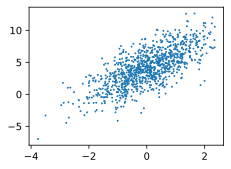

In [5]:
d2l.set_figsize()
d2l.plt.scatter(features[:,(0)].detach().numpy(),labels.detach().numpy(),1);

# 1.2读取数据集（迭代）

In [6]:
def data_iter(batch_size,features,labels):
    num_examples=len(features)
    indices=list(range(num_examples))
    random.shuffle(indices)
    for i in range(0,num_examples,batch_size):
        batch_indices=torch.tensor(indices[i:min(i+batch_size,num_examples)])
        yield features[batch_indices],labels[batch_indices]

In [7]:
batch_size=10
for X,y in data_iter(batch_size,features,labels):
    print(X,'\n',y)
    break

tensor([[-1.2595,  0.3579],
        [-1.5360, -1.8583],
        [-0.0175, -0.2598],
        [ 0.0531, -0.0291],
        [ 0.6621, -0.9708],
        [ 0.9832,  1.1761],
        [ 0.9235, -0.6417],
        [-0.8783,  0.7592],
        [-0.8532, -1.3276],
        [ 0.0220, -0.6919]]) 
 tensor([[ 2.4018],
        [-2.6078],
        [ 3.6467],
        [ 4.2516],
        [ 3.5934],
        [ 8.5283],
        [ 4.7681],
        [ 3.9797],
        [-0.1917],
        [ 2.8610]])


# 二.定义模型

# 2.1初始化超参数hyperparameters

In [8]:
w=torch.normal(0,0.01,size=(2,1),requires_grad=True)
b=torch.zeros(1,requires_grad=True)

In [9]:
w

tensor([[-0.0048],
        [-0.0118]], requires_grad=True)

In [10]:
b

tensor([0.], requires_grad=True)

# 2.2Models

In [11]:
def linreg(X,w,b):
    return torch.matmul(X,w)+b

In [12]:
def squared_loss(y_hat,y):
    return (y_hat-y.reshape(y_hat.shape))**2/2

In [13]:
def sgd(params,lr,batch_size):
    with torch.no_grad():
        for param in params:
            param-=lr*param.grad/batch_size
            param.grad.zero_()

In [14]:
lr=0.03
num_epochs=3
net=linreg
loss=squared_loss

In [15]:
for epoch in range(num_epochs):
    for X,y in data_iter(batch_size,features,labels):
        l=loss(net(X,w,b),y)
        l.sum().backward()
        sgd([w,b],lr,batch_size)
    with torch.no_grad():
        train_l=loss(net(features,w,b),labels)
        print(f'epoch {epoch+1},loss {float(train_l.mean()):f}')

epoch 1,loss 0.033448
epoch 2,loss 0.000147
epoch 3,loss 0.000051


In [16]:
w

tensor([[2.0000],
        [1.9996]], requires_grad=True)

In [17]:
true_w

tensor([2., 2.])